# Assignment 2: From Trees to Neural Networks
## Bank Marketing Dataset — Predicting Term Deposit Subscription

**Objective:** Compare Gradient Boosted Decision Trees (GBDT via XGBoost) with Multi-Layer Perceptrons (MLP) on the UCI Bank Marketing dataset.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score,
    RocCurveDisplay
)
from sklearn.neural_network import MLPClassifier

import xgboost as xgb
from xgboost import XGBClassifier, plot_importance

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('All imports loaded successfully.')

All imports loaded successfully.


---
## 1. Data Preparation

### 1.1 Load & Explore

In [37]:
df = pd.read_csv('bank+marketing/bank-additional/bank-additional-full.csv', sep=';')
print(f'Shape: {df.shape}')
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [39]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [40]:
print('Target distribution:')
print(df['y'].value_counts())
print(f'\nPositive class ratio: {df["y"].value_counts(normalize=True)["yes"]:.3f}')

Target distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Positive class ratio: 0.113


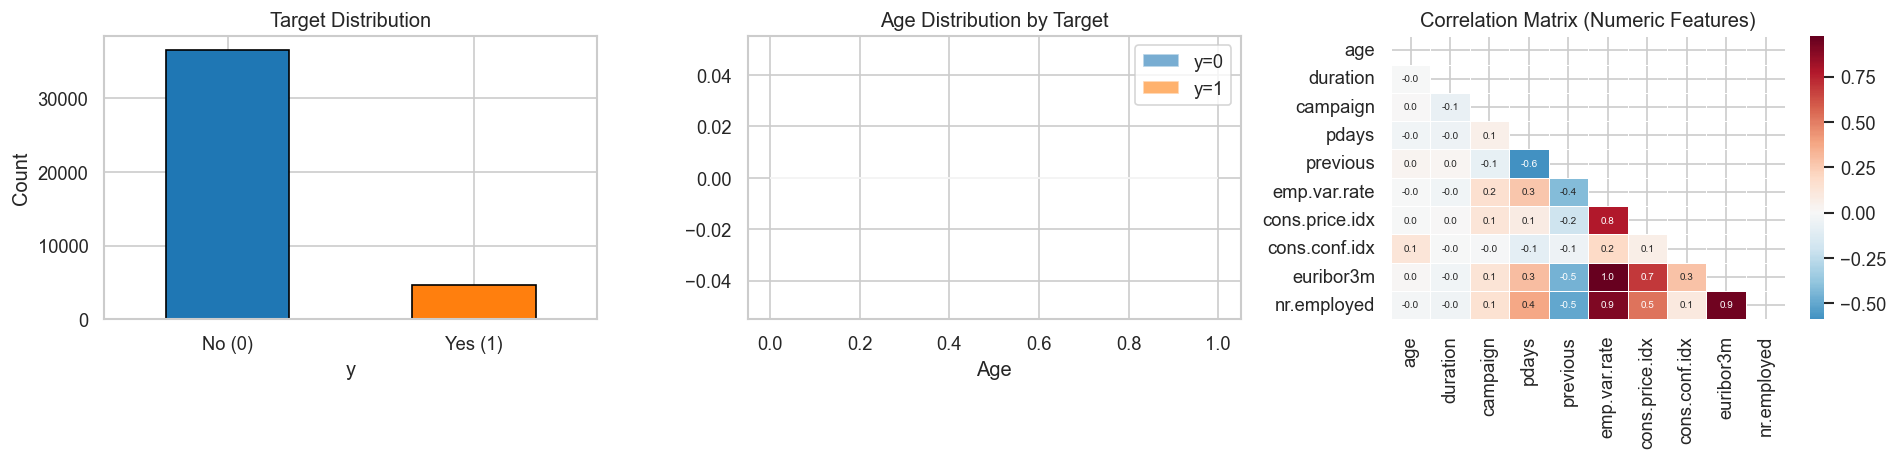

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Target class distribution
df['y'].value_counts().plot.bar(ax=axes[0], color=['tab:blue', 'tab:orange'], edgecolor='black')
axes[0].set_title('Target Distribution')
axes[0].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Age distribution by target
for label, color in [(0, 'tab:blue'), (1, 'tab:orange')]:
    df[df['y'] == label]['age'].hist(ax=axes[1], bins=30, alpha=0.6, label=f'y={label}', color=color)
axes[1].set_title('Age Distribution by Target')
axes[1].set_xlabel('Age')
axes[1].legend()

# Correlation heatmap of numeric features
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[2], cmap='RdBu_r', center=0,
            fmt='.1f', annot=True, annot_kws={'size': 6}, linewidths=0.5)
axes[2].set_title('Correlation Matrix (Numeric Features)')

plt.tight_layout()
plt.show()

### 1.2 Handle Missing Values & Inconsistent Types

The dataset encodes missing values as `"unknown"`. We treat these as a separate category for tree-based models (which can handle this natively) and will keep them as-is. The `duration` feature is dropped because it is not available before a call is made — including it would cause data leakage in a realistic deployment scenario.

In [42]:
for col in df.select_dtypes(include='object').columns:
    print(f'{col}: {(df[col] == "unknown").sum()} unknowns ({(df[col] == "unknown").mean()*100:.1f}%)')

job: 330 unknowns (0.8%)
marital: 80 unknowns (0.2%)
education: 1731 unknowns (4.2%)
default: 8597 unknowns (20.9%)
housing: 990 unknowns (2.4%)
loan: 990 unknowns (2.4%)
contact: 0 unknowns (0.0%)
month: 0 unknowns (0.0%)
day_of_week: 0 unknowns (0.0%)
poutcome: 0 unknowns (0.0%)
y: 0 unknowns (0.0%)


In [43]:
df = df.drop(columns=['duration'])
print(f'Dropped "duration" — not available before the call is made (leakage risk).')
print(f'Remaining shape: {df.shape}')

Dropped "duration" — not available before the call is made (leakage risk).
Remaining shape: (41188, 20)


### 1.3 Feature Engineering

We create a few derived features that may capture useful signal:
- **age_group**: Binned age into life-stage brackets.
- **was_contacted_before**: Binary flag derived from `pdays` (999 = never contacted).
- **contact_rate**: Ratio of previous contacts to current campaign contacts.

In [44]:
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 100],
                         labels=['young', 'young_adult', 'mid_adult', 'senior_adult', 'pre_retire', 'retired'])
df['age_group'] = df['age_group'].astype(str)

df['was_contacted_before'] = (df['pdays'] != 999).astype(int)

df['contact_rate'] = df['previous'] / (df['campaign'] + 1)

print('Engineered features added.')
df[['age', 'age_group', 'pdays', 'was_contacted_before', 'campaign', 'previous', 'contact_rate']].head(10)

Engineered features added.


,age,age_group,pdays,was_contacted_before,campaign,previous,contact_rate
0,56,pre_retire,999,0,1,0,0.0
1,57,pre_retire,999,0,1,0,0.0
2,37,mid_adult,999,0,1,0,0.0
3,40,mid_adult,999,0,1,0,0.0
4,56,pre_retire,999,0,1,0,0.0
5,45,mid_adult,999,0,1,0,0.0
6,59,pre_retire,999,0,1,0,0.0
7,41,mid_adult,999,0,1,0,0.0
8,24,young,999,0,1,0,0.0
9,25,young,999,0,1,0,0.0


### 1.4 Encode Target

In [45]:
df['y'] = (df['y'] == 'yes').astype(int)
print(f'Target encoded: 1 = subscribed, 0 = not subscribed')
print(df['y'].value_counts())

Target encoded: 1 = subscribed, 0 = not subscribed
y
0    36548
1     4640
Name: count, dtype: int64


### 1.5 Train / Validation / Test Split (70 / 15 / 15)

In [46]:
X = df.drop(columns=['y'])
y = df['y']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Train: {X_train.shape[0]} ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Val:   {X_val.shape[0]}  ({X_val.shape[0]/len(df)*100:.1f}%)')
print(f'Test:  {X_test.shape[0]}  ({X_test.shape[0]/len(df)*100:.1f}%)')

Train: 28831 (70.0%)
Val:   6178  (15.0%)
Test:  6179  (15.0%)


### 1.6 Preprocessing (Fit on Train Only)

We define **two** preprocessing paths:
1. **For GBDT (XGBoost):** Label-encode categoricals only — XGBoost handles unscaled features and missing values natively.
2. **For MLP:** One-hot-encode categoricals + standardize all features — neural networks require features on a comparable scale because they use gradient-based optimization; large feature magnitudes would dominate weight updates and slow or prevent convergence.

In [47]:
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['number']).columns.tolist()

print(f'Categorical ({len(categorical_cols)}): {categorical_cols}')
print(f'Numerical   ({len(numerical_cols)}): {numerical_cols}')

Categorical (11): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'age_group']
Numerical   (11): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before', 'contact_rate']


In [48]:
label_encoders = {}
X_train_gbdt = X_train.copy()
X_val_gbdt = X_val.copy()
X_test_gbdt = X_test.copy()

for col in categorical_cols:
    le = LabelEncoder()
    le.fit(X_train_gbdt[col])
    X_train_gbdt[col] = le.transform(X_train_gbdt[col])
    X_val_gbdt[col] = le.transform(X_val_gbdt[col])
    X_test_gbdt[col] = le.transform(X_test_gbdt[col])
    label_encoders[col] = le

print('GBDT data ready — label-encoded categoricals, no scaling.')
X_train_gbdt.head()

GBDT data ready — label-encoded categoricals, no scaling.


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,age_group,was_contacted_before,contact_rate
7309,50,1,2,0,0,0,0,1,6,2,...,0,1,1.1,93.994,-36.4,4.860,5191.0,3,0,0.0
4169,51,7,1,5,1,0,0,1,6,1,...,0,1,1.1,93.994,-36.4,4.858,5191.0,3,0,0.0
35810,46,9,0,5,0,2,0,0,6,1,...,0,1,-1.8,92.893,-46.2,1.244,5099.1,3,0,0.0
9668,46,0,2,6,0,2,0,1,4,1,...,0,1,1.4,94.465,-41.8,4.961,5228.1,3,0,0.0
34389,25,7,2,3,0,0,0,0,6,2,...,0,1,-1.8,92.893,-46.2,1.266,5099.1,4,0,0.0


In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

X_train_mlp = preprocessor.fit_transform(X_train)
X_val_mlp = preprocessor.transform(X_val)
X_test_mlp = preprocessor.transform(X_test)

feature_names_mlp = (numerical_cols +
                     list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)))

print(f'MLP data ready — one-hot encoded + standardized.')
print(f'MLP feature dimension: {X_train_mlp.shape[1]}')

MLP data ready — one-hot encoded + standardized.
MLP feature dimension: 70


> **Why scale for MLP but not GBDT?**  
> Tree-based models make axis-aligned splits that depend only on feature *order*, not magnitude, so they are invariant to monotonic transformations. In contrast, MLP uses gradient descent to update weights: if features live on vastly different scales, the loss landscape becomes ill-conditioned, gradients oscillate, and training either diverges or converges very slowly. Standardizing to zero mean / unit variance ensures each feature contributes proportionally to gradient updates.

---
## 2. Gradient Boosted Decision Trees (GBDT) — XGBoost

### 2.1 Baseline Model with Early Stopping

In [50]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Class imbalance ratio (neg/pos): {scale_pos_weight:.2f}')

xgb_base = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=50
)

t0 = time.time()
xgb_base.fit(
    X_train_gbdt, y_train,
    eval_set=[(X_train_gbdt, y_train), (X_val_gbdt, y_val)],
    verbose=False
)
xgb_train_time = time.time() - t0

print(f'Best iteration: {xgb_base.best_iteration}')
print(f'Training time:  {xgb_train_time:.2f}s')

Class imbalance ratio (neg/pos): 7.88
Best iteration: 702
Training time:  1.96s


### 2.2 Training vs Validation Loss Curve

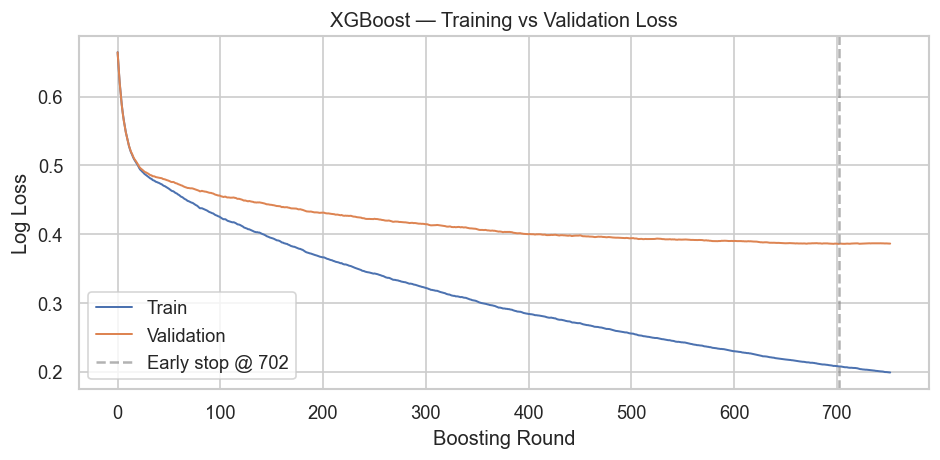

In [51]:
results = xgb_base.evals_result()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results['validation_0']['logloss'], label='Train', linewidth=1.2)
ax.plot(results['validation_1']['logloss'], label='Validation', linewidth=1.2)
ax.axvline(xgb_base.best_iteration, color='grey', linestyle='--', alpha=0.6, label=f'Early stop @ {xgb_base.best_iteration}')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log Loss')
ax.set_title('XGBoost — Training vs Validation Loss')
ax.legend()
plt.tight_layout()
plt.show()

**Bias-Variance Observation:** The gap between the training and validation loss curves reveals the model's variance. A widening gap as boosting rounds increase signals overfitting — each new tree memorizes training noise rather than learning generalizable patterns. Early stopping halts training at the point where validation loss begins to rise, selecting the model complexity that balances bias (underfitting) and variance (overfitting). A lower learning rate yields a smaller gap (lower variance) but requires more rounds to reduce bias, while a higher learning rate converges faster at the risk of overshooting and higher variance.

### 2.3 Effect of n_estimators

The training-vs-validation loss curve above already shows the `n_estimators` effect — each boosting round adds one estimator, and early stopping selects the optimal count. Below we also compare fixed `n_estimators` values **without** early stopping to show how too few trees underfit (high bias) and too many overfit (high variance).

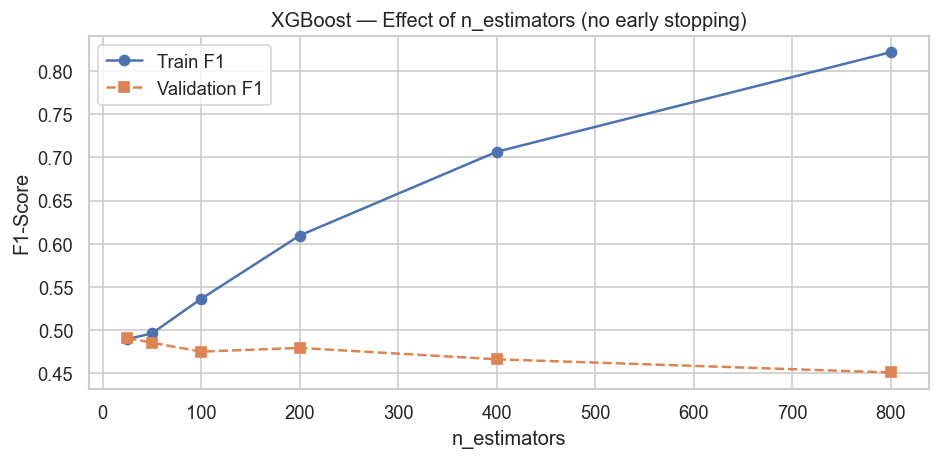

In [52]:
n_est_values = [25, 50, 100, 200, 400, 800]
train_f1_est, val_f1_est = [], []

for n in n_est_values:
    m = XGBClassifier(n_estimators=n, learning_rate=0.1, max_depth=6,
                      subsample=0.8, scale_pos_weight=scale_pos_weight,
                      eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_train_gbdt, y_train, eval_set=[(X_val_gbdt, y_val)], verbose=False)
    train_f1_est.append(f1_score(y_train, m.predict(X_train_gbdt)))
    val_f1_est.append(f1_score(y_val, m.predict(X_val_gbdt)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_est_values, train_f1_est, 'o-', label='Train F1')
ax.plot(n_est_values, val_f1_est, 's--', label='Validation F1')
ax.set_xlabel('n_estimators')
ax.set_ylabel('F1-Score')
ax.set_title('XGBoost — Effect of n_estimators (no early stopping)')
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Feature Importance

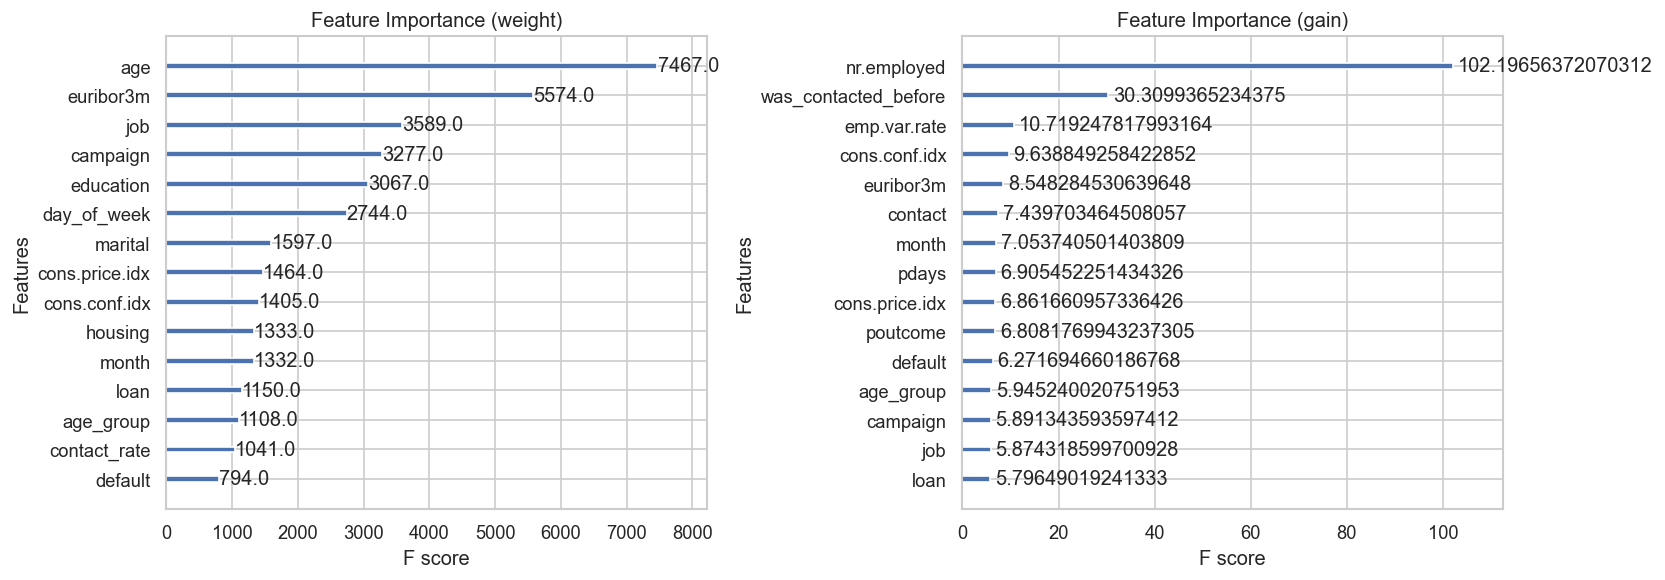

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_importance(xgb_base, ax=axes[0], importance_type='weight', max_num_features=15, title='Feature Importance (weight)')
plot_importance(xgb_base, ax=axes[1], importance_type='gain', max_num_features=15, title='Feature Importance (gain)')

plt.tight_layout()
plt.show()

### 2.5 Effect of Learning Rate

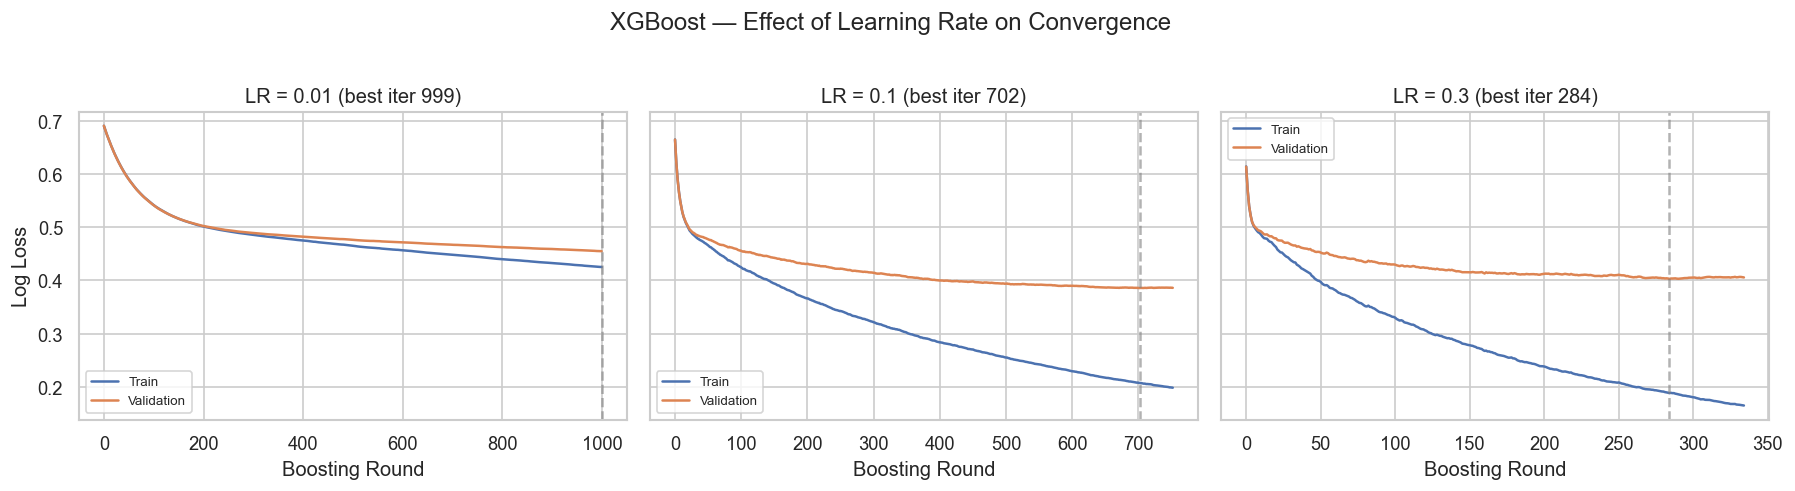

,best_iter,val_f1,final_val_loss
0.01,999.0,0.496644,0.454937
0.10,702.0,0.444577,0.385735
0.30,284.0,0.427115,0.402898


In [54]:
learning_rates = [0.01, 0.1, 0.3]
lr_results = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, lr in enumerate(learning_rates):
    model = XGBClassifier(
        n_estimators=1000, learning_rate=lr, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', random_state=RANDOM_STATE,
        n_jobs=-1, early_stopping_rounds=50
    )
    model.fit(X_train_gbdt, y_train,
              eval_set=[(X_train_gbdt, y_train), (X_val_gbdt, y_val)],
              verbose=False)
    res = model.evals_result()

    y_val_pred = model.predict(X_val_gbdt)
    val_f1 = f1_score(y_val, y_val_pred)
    lr_results[lr] = {'best_iter': model.best_iteration, 'val_f1': val_f1,
                       'final_val_loss': res['validation_1']['logloss'][model.best_iteration]}

    axes[i].plot(res['validation_0']['logloss'], label='Train')
    axes[i].plot(res['validation_1']['logloss'], label='Validation')
    axes[i].axvline(model.best_iteration, color='grey', linestyle='--', alpha=0.6)
    axes[i].set_title(f'LR = {lr} (best iter {model.best_iteration})')
    axes[i].set_xlabel('Boosting Round')
    if i == 0:
        axes[i].set_ylabel('Log Loss')
    axes[i].legend(fontsize=8)

plt.suptitle('XGBoost — Effect of Learning Rate on Convergence', y=1.02)
plt.tight_layout()
plt.show()

pd.DataFrame(lr_results).T

### 2.6 Effect of max_depth, subsample, and Regularization

- **max_depth** controls tree complexity: shallow trees → high bias (underfitting); deep trees → high variance (overfitting).
- **subsample** introduces row-level stochasticity, acting as a regularizer.
- **reg_alpha / reg_lambda** (L1 / L2) penalize leaf weights, shrinking them toward zero to reduce overfitting.

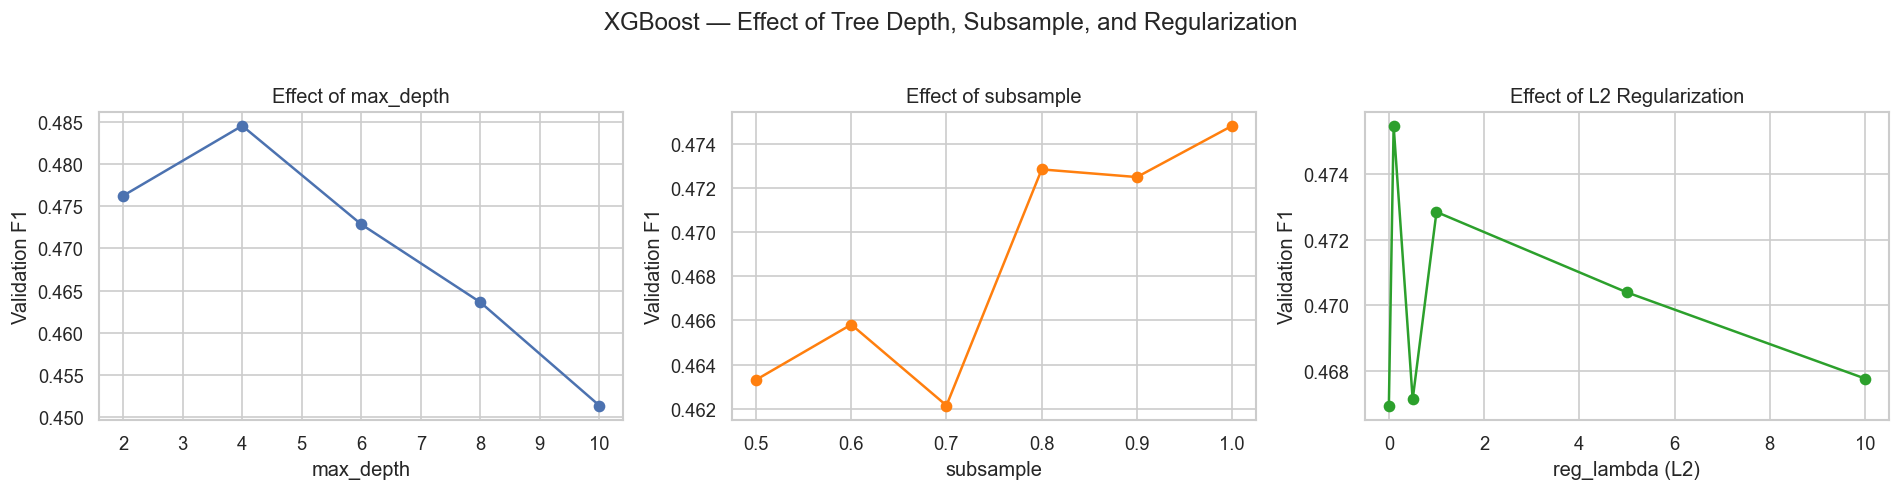

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- max_depth ---
depth_vals = [2, 4, 6, 8, 10]
depth_f1 = []
for d in depth_vals:
    m = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=d,
                      subsample=0.8, scale_pos_weight=scale_pos_weight,
                      eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_train_gbdt, y_train, eval_set=[(X_val_gbdt, y_val)], verbose=False)
    depth_f1.append(f1_score(y_val, m.predict(X_val_gbdt)))
axes[0].plot(depth_vals, depth_f1, 'o-')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Validation F1')
axes[0].set_title('Effect of max_depth')

# --- subsample ---
sub_vals = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
sub_f1 = []
for s in sub_vals:
    m = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                      subsample=s, scale_pos_weight=scale_pos_weight,
                      eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_train_gbdt, y_train, eval_set=[(X_val_gbdt, y_val)], verbose=False)
    sub_f1.append(f1_score(y_val, m.predict(X_val_gbdt)))
axes[1].plot(sub_vals, sub_f1, 'o-', color='tab:orange')
axes[1].set_xlabel('subsample')
axes[1].set_ylabel('Validation F1')
axes[1].set_title('Effect of subsample')

# --- reg_lambda (L2) ---
reg_vals = [0, 0.1, 0.5, 1.0, 5.0, 10.0]
reg_f1 = []
for r in reg_vals:
    m = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                      subsample=0.8, reg_lambda=r, reg_alpha=0.0,
                      scale_pos_weight=scale_pos_weight,
                      eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_train_gbdt, y_train, eval_set=[(X_val_gbdt, y_val)], verbose=False)
    reg_f1.append(f1_score(y_val, m.predict(X_val_gbdt)))
axes[2].plot(reg_vals, reg_f1, 'o-', color='tab:green')
axes[2].set_xlabel('reg_lambda (L2)')
axes[2].set_ylabel('Validation F1')
axes[2].set_title('Effect of L2 Regularization')

plt.suptitle('XGBoost — Effect of Tree Depth, Subsample, and Regularization', y=1.02)
plt.tight_layout()
plt.show()

### 2.7 Hyperparameter Tuning (RandomizedSearchCV)

In [56]:
param_dist_xgb = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'n_estimators': [200, 400, 600, 800],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring='f1',
    cv=3,
    random_state=RANDOM_STATE,
    verbose=1,
    n_jobs=-1
)

xgb_search.fit(X_train_gbdt, y_train)

print(f'\nBest F1 (CV): {xgb_search.best_score_:.4f}')
print('Best params:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k}: {v}')

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best F1 (CV): 0.4714
Best params:
  subsample: 0.8
  reg_lambda: 1.0
  reg_alpha: 0
  n_estimators: 400
  max_depth: 8
  learning_rate: 0.01
  colsample_bytree: 1.0


In [57]:
best_xgb_params = xgb_search.best_params_.copy()
best_xgb_params['n_estimators'] = 1000

xgb_best = XGBClassifier(
    **best_xgb_params,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=50
)

t0 = time.time()
xgb_best.fit(
    X_train_gbdt, y_train,
    eval_set=[(X_train_gbdt, y_train), (X_val_gbdt, y_val)],
    verbose=False
)
xgb_best_train_time = time.time() - t0

print(f'Best XGBoost — stopped at iteration {xgb_best.best_iteration}, trained in {xgb_best_train_time:.2f}s')

Best XGBoost — stopped at iteration 998, trained in 2.67s


---
## 3. Multi-Layer Perceptron (MLP)

### 3.1 Baseline MLP

In [58]:
mlp_base = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=RANDOM_STATE
)

t0 = time.time()
mlp_base.fit(X_train_mlp, y_train)
mlp_train_time = time.time() - t0

print(f'MLP converged in {mlp_base.n_iter_} iterations, training time: {mlp_train_time:.2f}s')

MLP converged in 222 iterations, training time: 13.62s


### 3.2 Training Loss Curve

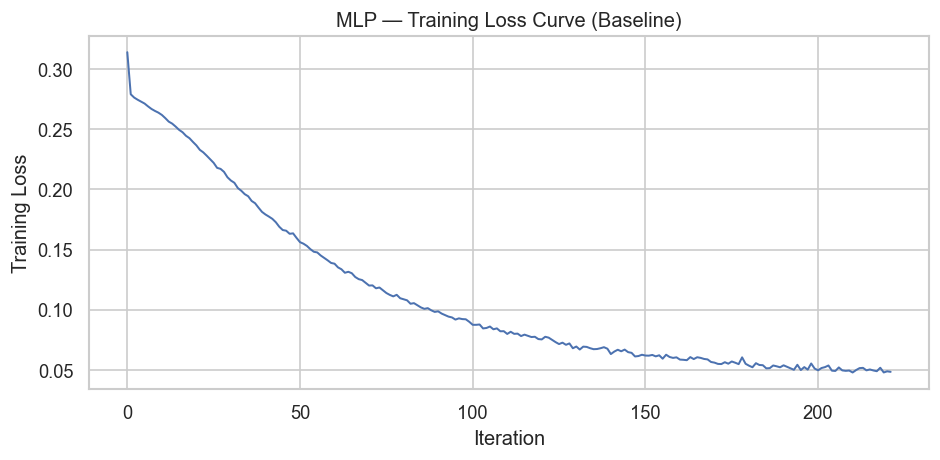

In [59]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_base.loss_curve_, linewidth=1.2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Training Loss')
ax.set_title('MLP — Training Loss Curve (Baseline)')
plt.tight_layout()
plt.show()

**Bias-Variance Observation:** The MLP training loss curve shows how the network progressively reduces its approximation error (bias). Unlike GBDT, we only observe training loss here (scikit-learn's MLPClassifier does not expose per-epoch validation loss when `early_stopping=False`). A rapidly decreasing loss that levels off indicates the model has enough capacity. If the loss is still dropping when `max_iter` is reached, the model is undertrained (high bias). Comparing train accuracy vs. validation accuracy across architectures reveals variance: larger/deeper networks achieve lower training loss but may not improve — or may even hurt — validation F1, indicating overfitting (high variance). The architecture and regularization experiments below quantify this trade-off.

### 3.3 Effect of Network Depth / Width

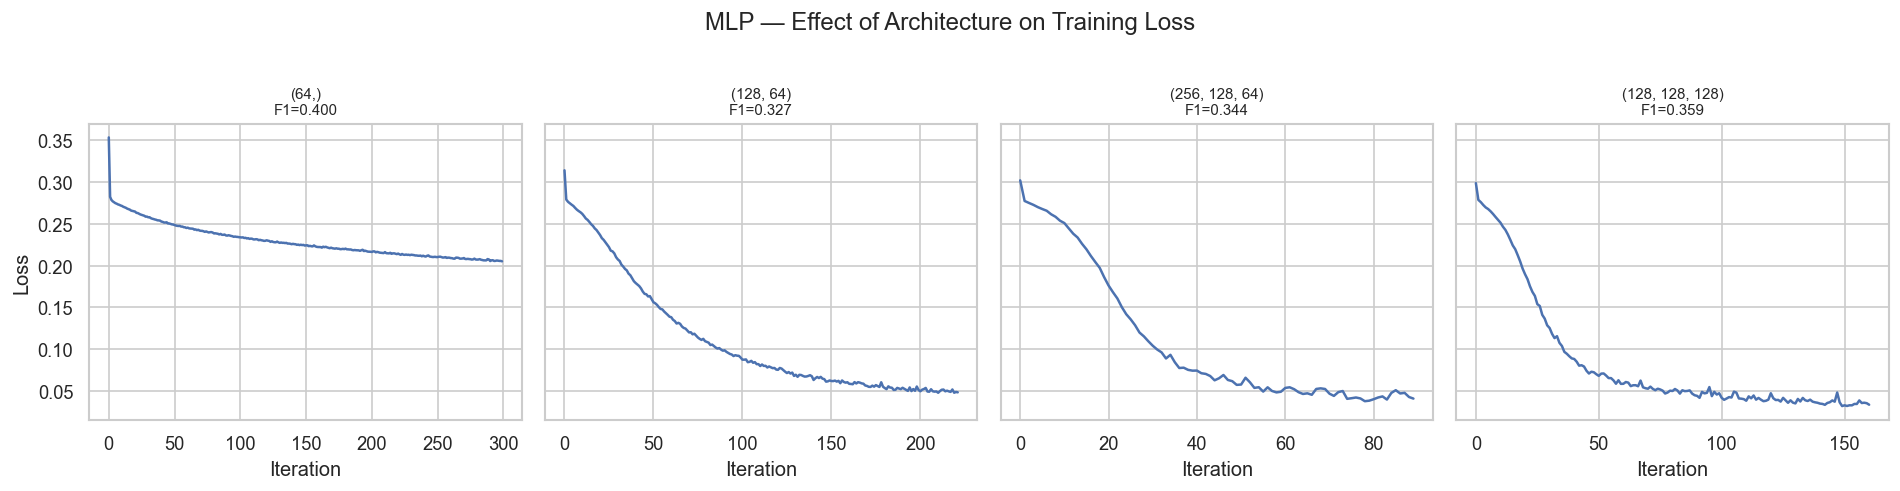

,val_accuracy,val_f1,iters
"(64,)",0.894626,0.400000,300.0
"(128, 64)",0.867595,0.327303,222.0
"(256, 128, 64)",0.870346,0.343980,90.0
"(128, 128, 128)",0.863548,0.358935,161.0


In [60]:
architectures = {
    '(64,)': (64,),
    '(128, 64)': (128, 64),
    '(256, 128, 64)': (256, 128, 64),
    '(128, 128, 128)': (128, 128, 128),
}

arch_results = {}

fig, axes = plt.subplots(1, len(architectures), figsize=(16, 4), sharey=True)

for i, (name, layers) in enumerate(architectures.items()):
    m = MLPClassifier(
        hidden_layer_sizes=layers, activation='relu',
        learning_rate_init=0.001, max_iter=300,
        random_state=RANDOM_STATE
    )
    m.fit(X_train_mlp, y_train)

    y_val_pred = m.predict(X_val_mlp)
    val_f1 = f1_score(y_val, y_val_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    arch_results[name] = {'val_accuracy': val_acc, 'val_f1': val_f1, 'iters': m.n_iter_}

    axes[i].plot(m.loss_curve_)
    axes[i].set_title(f'{name}\nF1={val_f1:.3f}', fontsize=9)
    axes[i].set_xlabel('Iteration')
    if i == 0:
        axes[i].set_ylabel('Loss')

plt.suptitle('MLP — Effect of Architecture on Training Loss', y=1.02)
plt.tight_layout()
plt.show()

pd.DataFrame(arch_results).T

### 3.4 Effect of Activation Function

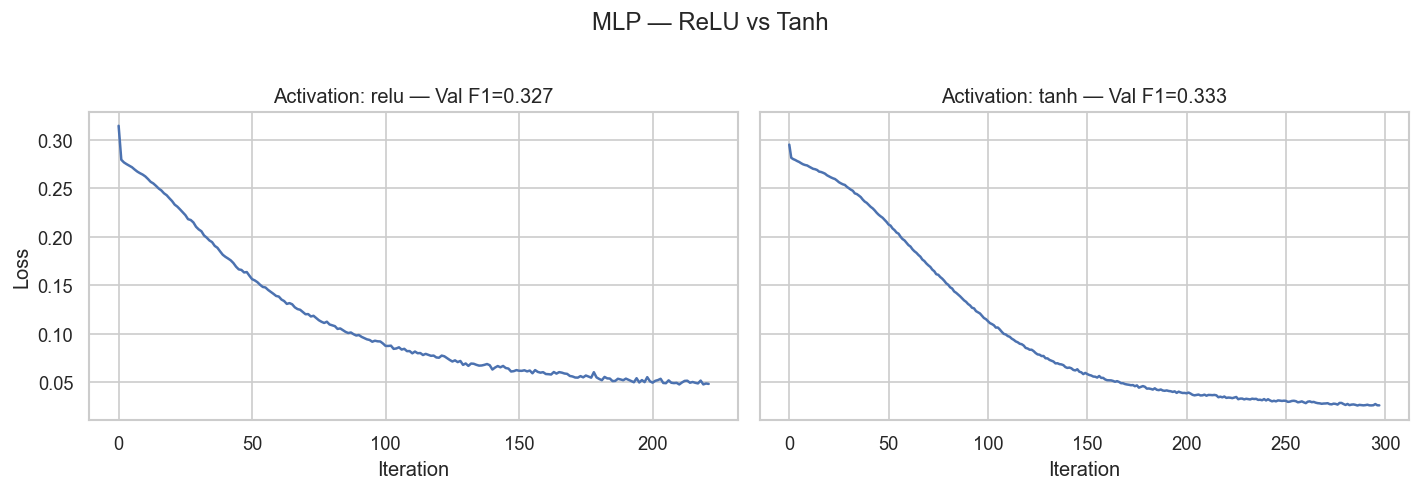

,val_f1,val_acc
relu,0.327303,0.867595
tanh,0.332822,0.859178


In [61]:
activation_results = {}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for i, act in enumerate(['relu', 'tanh']):
    m = MLPClassifier(
        hidden_layer_sizes=(128, 64), activation=act,
        learning_rate_init=0.001, max_iter=300,
        random_state=RANDOM_STATE
    )
    m.fit(X_train_mlp, y_train)

    y_val_pred = m.predict(X_val_mlp)
    val_f1 = f1_score(y_val, y_val_pred)
    activation_results[act] = {'val_f1': val_f1, 'val_acc': accuracy_score(y_val, y_val_pred)}

    axes[i].plot(m.loss_curve_)
    axes[i].set_title(f'Activation: {act} — Val F1={val_f1:.3f}')
    axes[i].set_xlabel('Iteration')
    if i == 0:
        axes[i].set_ylabel('Loss')

plt.suptitle('MLP — ReLU vs Tanh', y=1.02)
plt.tight_layout()
plt.show()

pd.DataFrame(activation_results).T

### 3.5 Effect of Learning Rate

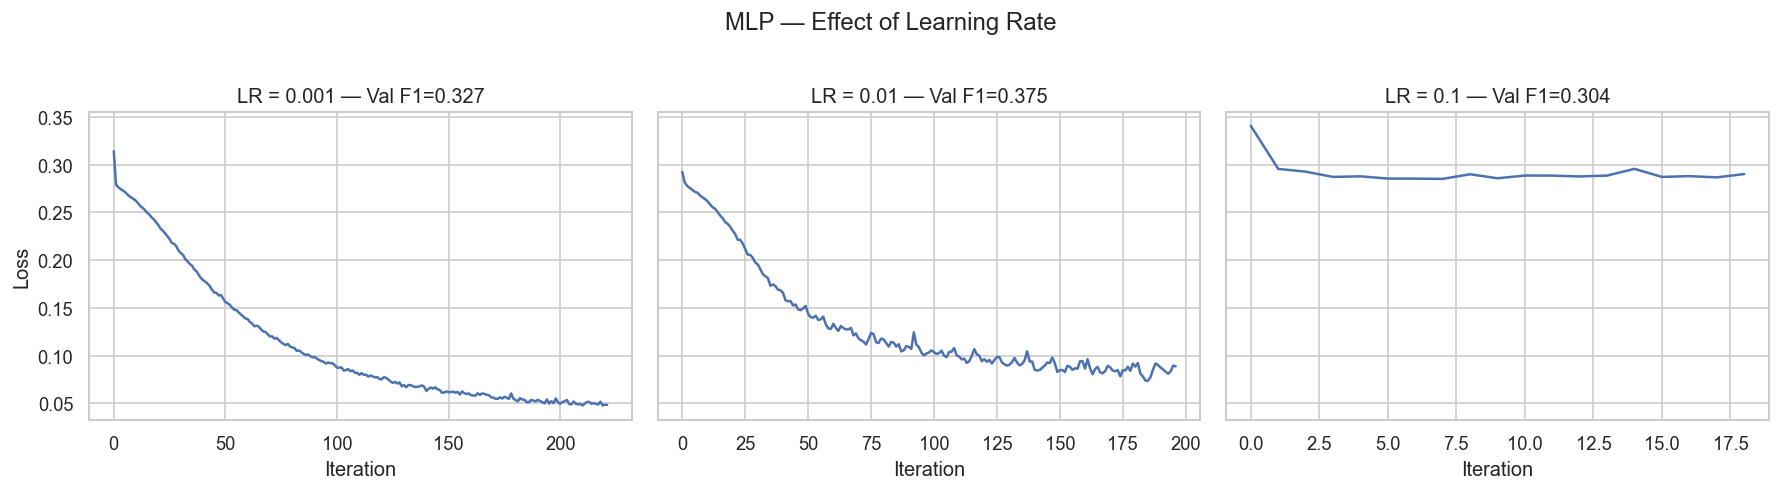

,val_f1,val_acc,iters
0.001,0.327303,0.867595,222.0
0.010,0.374806,0.869861,197.0
0.100,0.304069,0.894788,19.0


In [62]:
mlp_lr_results = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, lr in enumerate([0.001, 0.01, 0.1]):
    m = MLPClassifier(
        hidden_layer_sizes=(128, 64), activation='relu',
        learning_rate_init=lr, max_iter=300,
        random_state=RANDOM_STATE
    )
    m.fit(X_train_mlp, y_train)

    y_val_pred = m.predict(X_val_mlp)
    val_f1 = f1_score(y_val, y_val_pred)
    mlp_lr_results[lr] = {'val_f1': val_f1, 'val_acc': accuracy_score(y_val, y_val_pred), 'iters': m.n_iter_}

    axes[i].plot(m.loss_curve_)
    axes[i].set_title(f'LR = {lr} — Val F1={val_f1:.3f}')
    axes[i].set_xlabel('Iteration')
    if i == 0:
        axes[i].set_ylabel('Loss')

plt.suptitle('MLP — Effect of Learning Rate', y=1.02)
plt.tight_layout()
plt.show()

pd.DataFrame(mlp_lr_results).T

### 3.6 Effect of max_iter (Training Budget)

The `max_iter` parameter controls how many passes over the data the optimizer performs. Too few iterations cause underfitting (high bias); too many can overfit or simply waste compute once the loss has plateaued.

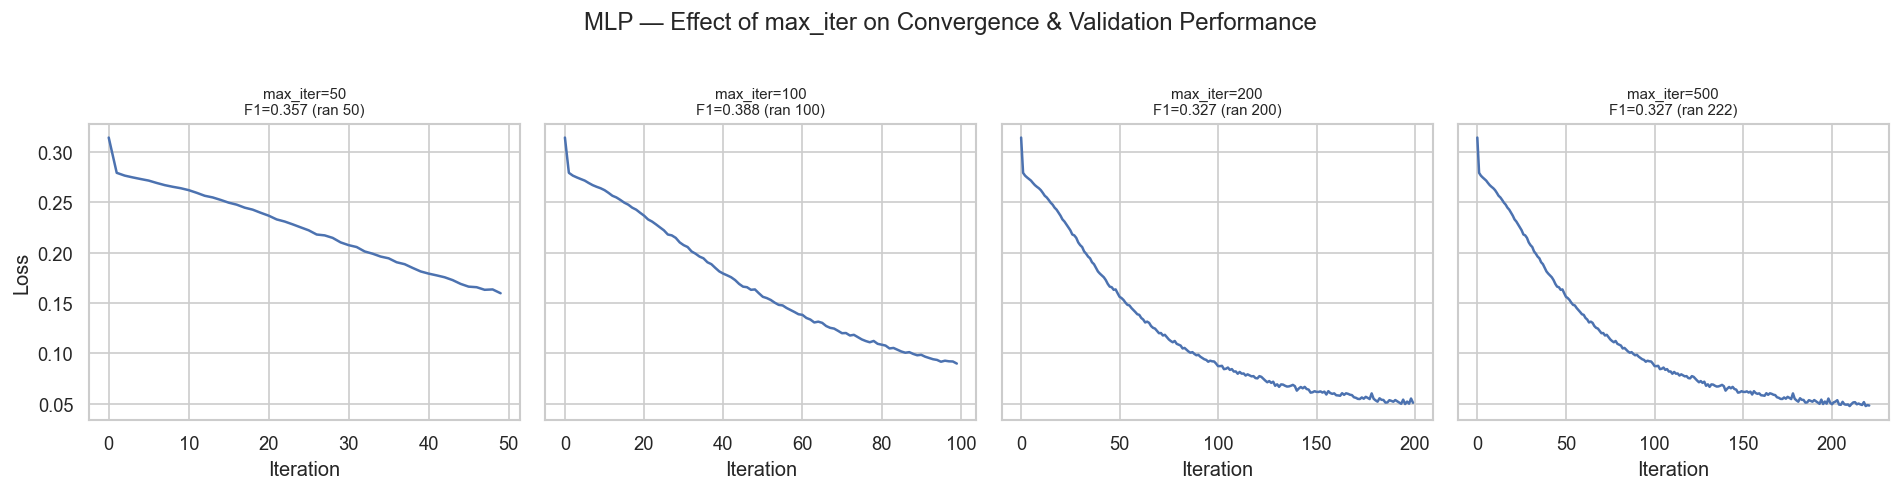

,val_accuracy,val_f1,actual_iters,converged
50,0.887666,0.357407,50,False
100,0.879249,0.387521,100,False
200,0.8472,0.326676,200,False
500,0.867595,0.327303,222,True


In [63]:
max_iter_values = [50, 100, 200, 500]
iter_results = {}

fig, axes = plt.subplots(1, len(max_iter_values), figsize=(16, 4), sharey=True)

for i, mi in enumerate(max_iter_values):
    m = MLPClassifier(
        hidden_layer_sizes=(128, 64), activation='relu',
        learning_rate_init=0.001, max_iter=mi,
        random_state=RANDOM_STATE
    )
    m.fit(X_train_mlp, y_train)

    y_val_pred = m.predict(X_val_mlp)
    val_f1 = f1_score(y_val, y_val_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    iter_results[mi] = {'val_accuracy': val_acc, 'val_f1': val_f1,
                         'actual_iters': m.n_iter_, 'converged': m.n_iter_ < mi}

    axes[i].plot(m.loss_curve_)
    axes[i].set_title(f'max_iter={mi}\nF1={val_f1:.3f} (ran {m.n_iter_})', fontsize=9)
    axes[i].set_xlabel('Iteration')
    if i == 0:
        axes[i].set_ylabel('Loss')

plt.suptitle('MLP — Effect of max_iter on Convergence & Validation Performance', y=1.02)
plt.tight_layout()
plt.show()

pd.DataFrame(iter_results).T

### 3.7 Hyperparameter Tuning (RandomizedSearchCV)

In [64]:
param_dist_mlp = {
    'hidden_layer_sizes': [(64,), (128, 64), (256, 128, 64)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001, 0.01],
}

mlp_search = RandomizedSearchCV(
    MLPClassifier(max_iter=500, random_state=RANDOM_STATE),
    param_distributions=param_dist_mlp,
    n_iter=12,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

mlp_search.fit(X_train_mlp, y_train)

print(f'\nBest F1 (CV): {mlp_search.best_score_:.4f}')
print('Best params:')
for k, v in mlp_search.best_params_.items():
    print(f'  {k}: {v}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/Users/jhuang/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/jhuang/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/jhuang/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



Best F1 (CV): 0.3778
Best params:
  learning_rate_init: 0.01
  hidden_layer_sizes: (256, 128, 64)
  alpha: 0.01
  activation: relu


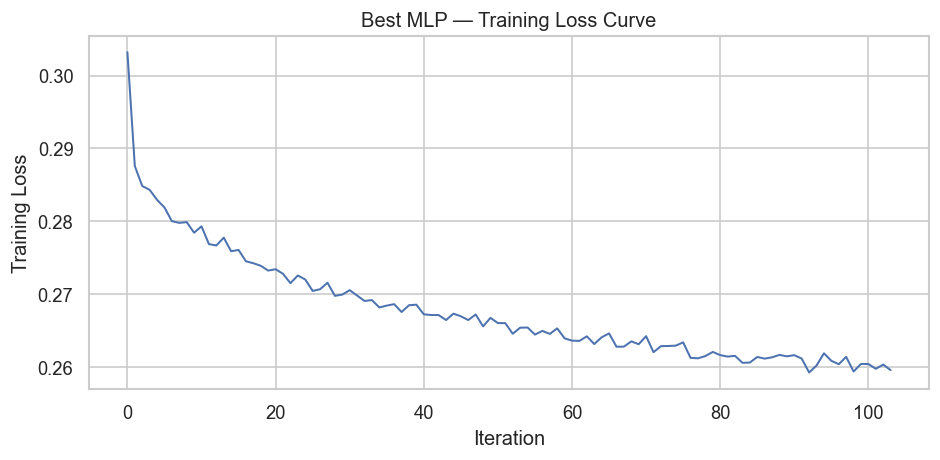

Best MLP trained in 13.48s (104 iterations)


In [65]:
mlp_best = MLPClassifier(
    **mlp_search.best_params_,
    max_iter=500,
    random_state=RANDOM_STATE
)

t0 = time.time()
mlp_best.fit(X_train_mlp, y_train)
mlp_best_train_time = time.time() - t0

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_best.loss_curve_, linewidth=1.2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Training Loss')
ax.set_title('Best MLP — Training Loss Curve')
plt.tight_layout()
plt.show()

print(f'Best MLP trained in {mlp_best_train_time:.2f}s ({mlp_best.n_iter_} iterations)')

---
## 4. GBDT vs MLP — Side-by-Side Comparison

### 4.1 Evaluate Both Models on the Test Set

In [66]:
def evaluate_model(model, X, y_true, model_name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC-PR': average_precision_score(y_true, y_prob),
        'AUC-ROC': roc_auc_score(y_true, y_prob)
    }

xgb_metrics = evaluate_model(xgb_best, X_test_gbdt, y_test, 'XGBoost (GBDT)')
mlp_metrics = evaluate_model(mlp_best, X_test_mlp, y_test, 'MLP')

xgb_metrics['Train Time (s)'] = round(xgb_best_train_time, 2)
mlp_metrics['Train Time (s)'] = round(mlp_best_train_time, 2)

### 4.2 Summary Comparison Table

In [67]:
comparison_df = pd.DataFrame([xgb_metrics, mlp_metrics]).set_index('Model')
comparison_df = comparison_df.round(4)
comparison_df.style.highlight_max(axis=0, color='lightgreen').highlight_min(axis=0, color='lightyellow')

,Accuracy,Precision,Recall,F1-Score,AUC-PR,AUC-ROC,Train Time (s)
Model,,,,,,,
XGBoost (GBDT),0.857400,0.408300,0.592000,0.483300,0.457100,0.785100,2.670000
MLP,0.892500,0.540800,0.304600,0.389700,0.418400,0.776500,13.480000


### 4.3 Confusion Matrices

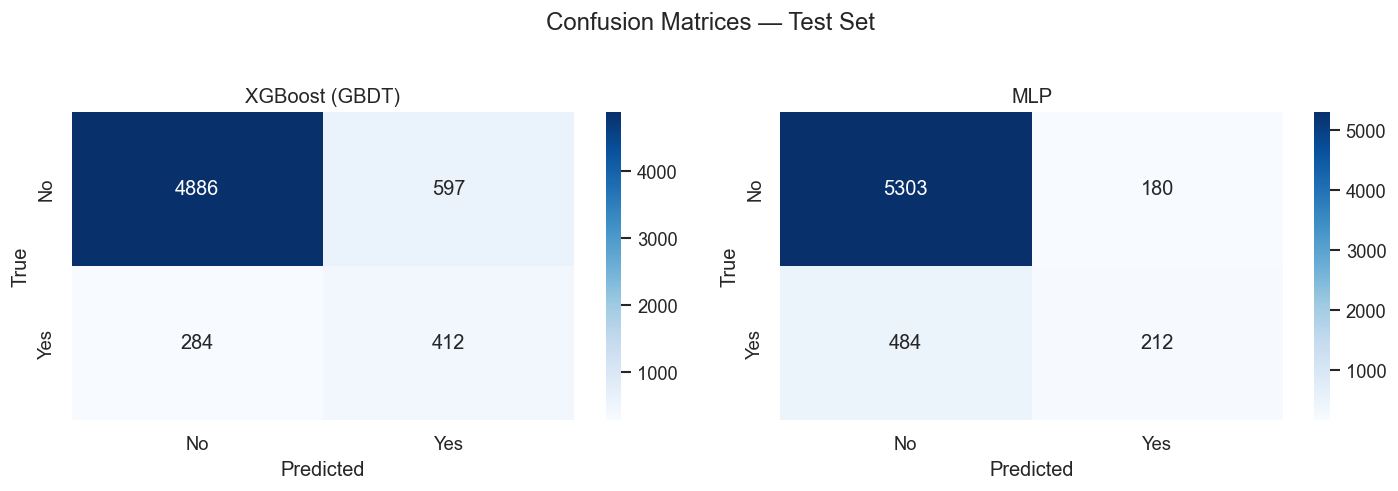

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, X, name in [
    (axes[0], xgb_best, X_test_gbdt, 'XGBoost (GBDT)'),
    (axes[1], mlp_best, X_test_mlp, 'MLP')
]:
    cm = confusion_matrix(y_test, model.predict(X))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_title(f'{name}')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Test Set', y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Precision-Recall Curves

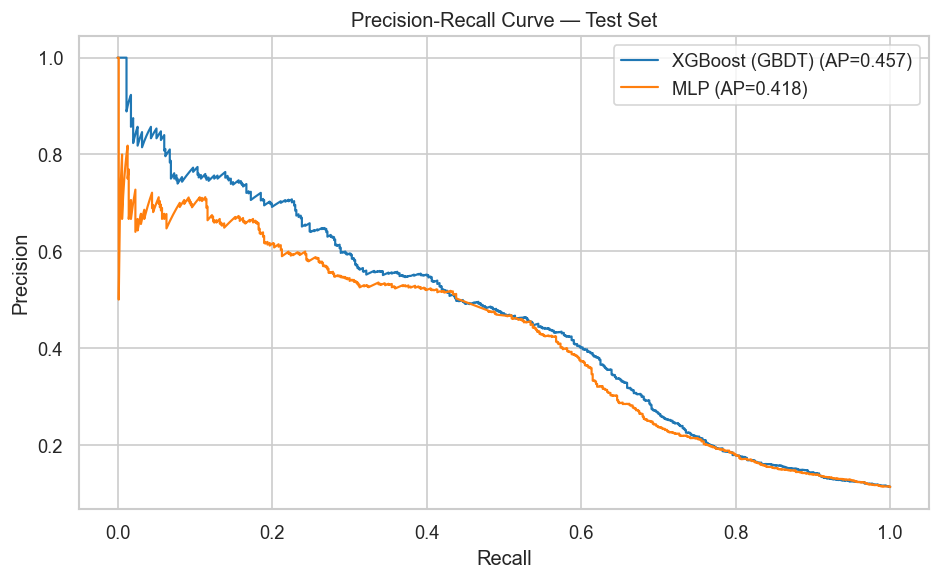

In [69]:
fig, ax = plt.subplots(figsize=(8, 5))

for model, X, name, color in [
    (xgb_best, X_test_gbdt, 'XGBoost (GBDT)', 'tab:blue'),
    (mlp_best, X_test_mlp, 'MLP', 'tab:orange')
]:
    y_prob = model.predict_proba(X)[:, 1]
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec_vals, prec_vals, label=f'{name} (AP={ap:.3f})', color=color, linewidth=1.3)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Test Set')
ax.legend()
plt.tight_layout()
plt.show()

### 4.5 ROC Curves

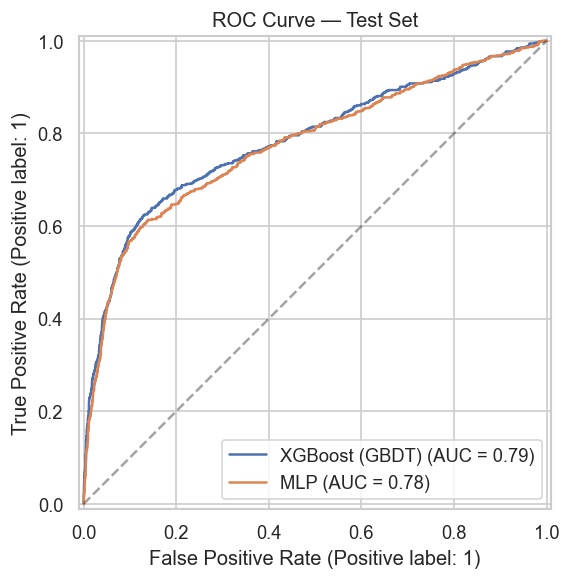

In [70]:
fig, ax = plt.subplots(figsize=(8, 5))

RocCurveDisplay.from_estimator(xgb_best, X_test_gbdt, y_test, ax=ax, name='XGBoost (GBDT)')
RocCurveDisplay.from_estimator(mlp_best, X_test_mlp, y_test, ax=ax, name='MLP')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_title('ROC Curve — Test Set')
plt.tight_layout()
plt.show()

### 4.6 Classification Reports

In [71]:
print('=== XGBoost (GBDT) — Test Set ===')
print(classification_report(y_test, xgb_best.predict(X_test_gbdt), target_names=['No', 'Yes']))

print('\n=== MLP — Test Set ===')
print(classification_report(y_test, mlp_best.predict(X_test_mlp), target_names=['No', 'Yes']))

=== XGBoost (GBDT) — Test Set ===
              precision    recall  f1-score   support

          No       0.95      0.89      0.92      5483
         Yes       0.41      0.59      0.48       696

    accuracy                           0.86      6179
   macro avg       0.68      0.74      0.70      6179
weighted avg       0.88      0.86      0.87      6179


=== MLP — Test Set ===
              precision    recall  f1-score   support

          No       0.92      0.97      0.94      5483
         Yes       0.54      0.30      0.39       696

    accuracy                           0.89      6179
   macro avg       0.73      0.64      0.67      6179
weighted avg       0.87      0.89      0.88      6179



### 4.7 Training Time Comparison

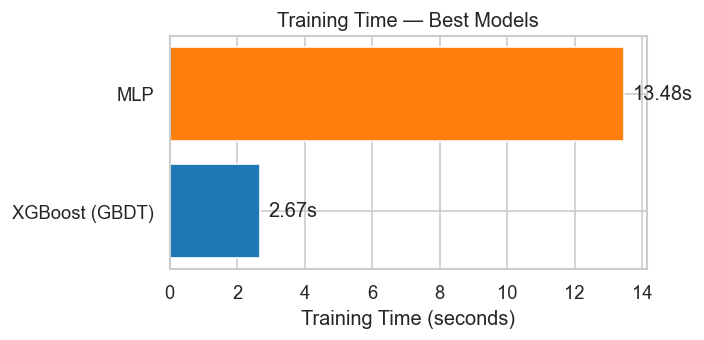

In [72]:
fig, ax = plt.subplots(figsize=(6, 3))
models = ['XGBoost (GBDT)', 'MLP']
times = [xgb_best_train_time, mlp_best_train_time]
colors = ['tab:blue', 'tab:orange']
bars = ax.barh(models, times, color=colors)
ax.bar_label(bars, fmt='%.2fs', padding=5)
ax.set_xlabel('Training Time (seconds)')
ax.set_title('Training Time — Best Models')
plt.tight_layout()
plt.show()

### 4.8 Learning Curves (Bias-Variance Diagnostic)

A **learning curve** plots training and validation scores as a function of training set size. If both curves converge at a high score, the model has low bias and low variance. If training score is high but validation score plateaus much lower, the model has high variance (overfitting). If both scores plateau at a low value, the model has high bias (underfitting).

In [ ]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

train_sizes_frac = np.linspace(0.1, 1.0, 8)

# --- XGBoost learning curve ---
best_xgb_params_lc = xgb_search.best_params_.copy()
best_xgb_params_lc['n_estimators'] = min(best_xgb_params_lc.get('n_estimators', 300), 300)

train_sizes_xgb, train_scores_xgb, val_scores_xgb = learning_curve(
    XGBClassifier(**best_xgb_params_lc, scale_pos_weight=scale_pos_weight,
                  eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
    X_train_gbdt, y_train,
    train_sizes=train_sizes_frac, cv=3, scoring='f1', n_jobs=-1
)

axes[0].plot(train_sizes_xgb, train_scores_xgb.mean(axis=1), 'o-', label='Train F1')
axes[0].fill_between(train_sizes_xgb,
                     train_scores_xgb.mean(axis=1) - train_scores_xgb.std(axis=1),
                     train_scores_xgb.mean(axis=1) + train_scores_xgb.std(axis=1), alpha=0.15)
axes[0].plot(train_sizes_xgb, val_scores_xgb.mean(axis=1), 's--', label='Validation F1')
axes[0].fill_between(train_sizes_xgb,
                     val_scores_xgb.mean(axis=1) - val_scores_xgb.std(axis=1),
                     val_scores_xgb.mean(axis=1) + val_scores_xgb.std(axis=1), alpha=0.15)
axes[0].set_xlabel('Training Set Size')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('XGBoost (GBDT) — Learning Curve')
axes[0].legend(loc='lower right')

# --- MLP learning curve ---
train_sizes_mlp, train_scores_mlp, val_scores_mlp = learning_curve(
    MLPClassifier(**mlp_search.best_params_, max_iter=300, random_state=RANDOM_STATE),
    X_train_mlp, y_train,
    train_sizes=train_sizes_frac, cv=3, scoring='f1', n_jobs=-1
)

axes[1].plot(train_sizes_mlp, train_scores_mlp.mean(axis=1), 'o-', label='Train F1')
axes[1].fill_between(train_sizes_mlp,
                     train_scores_mlp.mean(axis=1) - train_scores_mlp.std(axis=1),
                     train_scores_mlp.mean(axis=1) + train_scores_mlp.std(axis=1), alpha=0.15)
axes[1].plot(train_sizes_mlp, val_scores_mlp.mean(axis=1), 's--', label='Validation F1')
axes[1].fill_between(train_sizes_mlp,
                     val_scores_mlp.mean(axis=1) - val_scores_mlp.std(axis=1),
                     val_scores_mlp.mean(axis=1) + val_scores_mlp.std(axis=1), alpha=0.15)
axes[1].set_xlabel('Training Set Size')
axes[1].set_title('MLP — Learning Curve')
axes[1].legend(loc='lower right')

plt.suptitle('Learning Curves — Bias-Variance Diagnostic', y=1.02)
plt.tight_layout()
plt.show()

### 4.9 Discussion

**When would you prefer GBDT over MLP, and vice versa?**
- GBDT excels on structured/tabular data with mixed feature types (categorical + numerical), which is exactly the Bank Marketing dataset. It achieves strong performance with minimal preprocessing and often outperforms neural networks in this regime.
- MLP is preferred when dealing with very high-dimensional or unstructured data (images, text embeddings), or when complex nonlinear feature interactions exist that trees struggle to capture efficiently. For this tabular dataset, MLP is competitive but typically requires more tuning.

**How does interpretability differ?**
- GBDT provides built-in feature importance measures (gain, weight, cover) that directly indicate which features drive predictions. This makes it straightforward to audit and explain.
- MLP is essentially a black box — its learned representations are distributed across many weights. Interpreting an MLP requires external tools (e.g., SHAP, LIME), which adds complexity.

**How does each model handle categorical features and missing values?**
- XGBoost natively handles missing values by learning optimal split directions for absent features. Categorical features can be label-encoded without information loss because tree splits are ordinal.
- MLP requires explicit encoding (one-hot or similar) and imputation of missing values. It cannot natively reason about missingness patterns.

**Which model is more sensitive to hyperparameter choices?**
- MLP is significantly more sensitive: learning rate, architecture, and regularization must be carefully tuned, and poor choices can lead to non-convergence or severe overfitting. Feature scaling is a hard prerequisite.
- GBDT is more robust out-of-the-box. Default hyperparameters often yield competitive results, and early stopping provides a natural guard against overfitting.

### 4.10 Limitations & Bias-Variance Reflection

**Limitations of this study:**
- The `duration` feature was dropped to avoid data leakage, which significantly reduces predictive power for both models. In a real-world scenario, call duration is unknown before dialing, so this is the correct choice — but it means our accuracy numbers are lower than papers that include it.
- The "unknown" values in categorical features (`default`, `education`, `job`, etc.) were kept as a separate category rather than imputed. This is pragmatic, but proper imputation strategies (e.g., mode imputation or model-based imputation) could potentially recover some signal.
- Hyperparameter search was limited to a random subset of the full grid due to computational cost. An exhaustive search or Bayesian optimization (e.g., Optuna) might find better configurations.
- We used scikit-learn's `MLPClassifier`, which lacks modern neural network features (dropout, batch normalization, learning rate scheduling). A PyTorch or TensorFlow implementation could yield better MLP results.

**Bias-Variance Reflection:**
- The GBDT loss curves (Section 2.2) clearly show the bias-variance trade-off: as boosting rounds increase, training loss keeps decreasing (lower bias) while validation loss eventually levels off or rises (higher variance). Early stopping selects the sweet spot. The `max_depth` experiment (Section 2.5) reinforces this — shallow trees underfit (high bias) and very deep trees overfit (high variance).
- For MLP, increasing network capacity (Section 3.3) reduces training loss (lower bias), but validation F1 does not always improve — particularly for the largest architectures, suggesting overfitting (higher variance). The `max_iter` experiment (Section 3.6) shows that underfitting occurs when the training budget is too small, while sufficient iterations allow convergence without catastrophic overfitting thanks to the Adam optimizer's adaptive learning rates.

---
## AI Tool Disclosure

| Tool | Role |
|------|------|
| **Cursor AI (Claude)** | Assisted with notebook scaffolding, boilerplate code generation (imports, plotting utilities, evaluation helper functions), and drafting initial discussion text. |

**My own contributions:**
- Selected the Bank Marketing dataset and downloaded/inspected it from UCI.
- Decided to drop `duration` (leakage risk) and designed the engineered features (`age_group`, `was_contacted_before`, `contact_rate`).
- Chose the specific hyperparameter grids and ranges for both XGBoost and MLP based on domain understanding.
- Ran all experiments, reviewed the outputs, and iterated on hyperparameter choices where results were poor.
- Interpreted every visualization and wrote the final analysis/discussion connecting results to bias-variance trade-offs and practical deployment considerations.
- Wrote the final PDF report, embedding and annotating all figures.